### Animal Faces Classification Task: Understanding Underfitting, Overfitting, Regularization, Dropout and Hyperparameter Tuning and reviweing validation

In [1]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , Input , Flatten
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import kagglehub
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage.transform import resize

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import kagglehub

# Download dataset
path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Path to dataset files:", path)

# Define paths
data_dir = os.path.join(path, 'afhq')
train_dir = os.path.join(data_dir, 'train')
test_dir = os.path.join(data_dir, 'val')

# ImageDataGenerators
train_datagen = ImageDataGenerator(rescale=1./255)
test_val_datagen = ImageDataGenerator(rescale=1./255)

# Train generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(512, 512),
    batch_size=128,
    class_mode='categorical',
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(512, 512),
    class_mode='categorical'
)

def extract_hog_features(images, resize_shape=(128, 128)):
    hog_features = []
    for img in images:
        # Convert to grayscale (HOG is usually single-channel)
        gray = rgb2gray(img)
        # Resize for uniformity
        gray = resize(gray, resize_shape)
        # Extract HOG feature vector
        features = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        hog_features.append(features)
    return np.array(hog_features)

X_all = []
y_all = []
print(range(len(train_generator)))
for i in range(len(train_generator)):
    #append images and labels from each batch
    images, labels = next(train_generator)
    images = extract_hog_features(images)
    X_all.append(images)
    y_all.append(labels)
X_all = np.vstack(X_all)
y_all = np.vstack(y_all)

print(f"Number of batches: {X_all.shape} , {y_all.shape}")
print(f"Train samples: {train_generator.samples}")
print(f"Test samples: {test_generator.samples}")


Using Colab cache for faster access to the 'animal-faces' dataset.
Path to dataset files: /kaggle/input/animal-faces
Found 14630 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.
range(0, 115)
Number of batches: (14630, 8100) , (14630, 3)
Train samples: 14630
Test samples: 1500


(512, 512, 3)
(512, 512, 3)
(512, 512, 3)
(512, 512, 3)


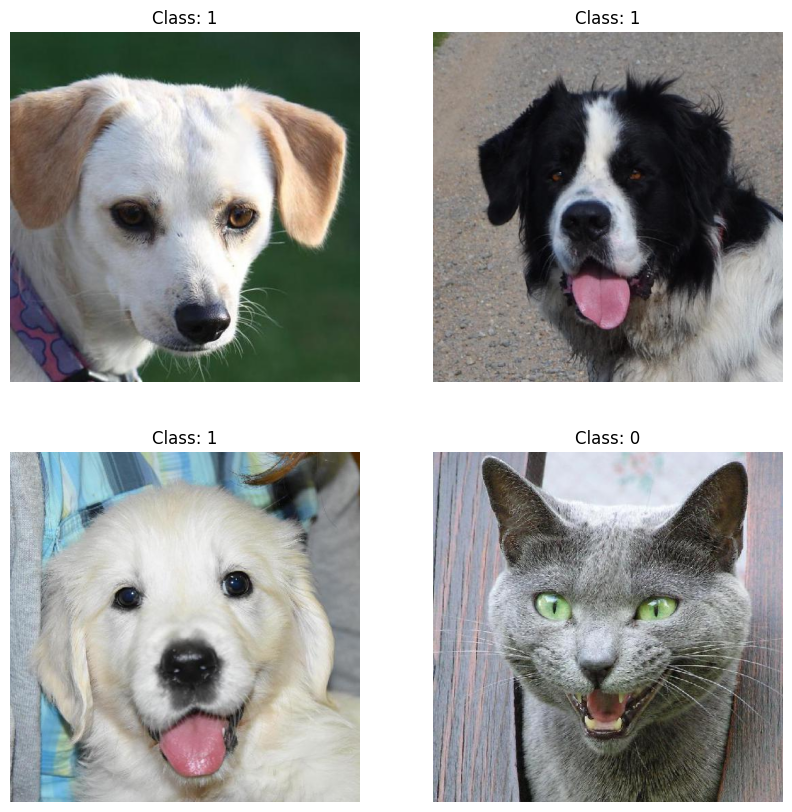

In [3]:
# Optional: Visualize a batch of images to confirm loading
import matplotlib.pyplot as plt

images, labels = next(test_generator)  # Get one batch
plt.figure(figsize=(10,10))
for i in range(4):  # Show first 4 images
    plt.subplot(2, 2, i+1)
    print(images[i].shape)
    plt.imshow(images[i])
    plt.title(f'Class: {labels[i].argmax()}')
    plt.axis('off')
plt.show()

In [4]:
# Function to plot training history (accuracy and loss curves)
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()



X_test = []
y_test = []
print(range(len(test_generator)))
for i in range(len(test_generator)):
    #append images and labels from each batch
    images, labels = next(test_generator)
    images = extract_hog_features(images)
    X_test.append(images)
    y_test.append(labels)
X_test = np.vstack(X_test)
y_test = np.vstack(y_test)

# Function to evaluate on test set
def evaluate_model(model , isHog):
    if isHog:
        test_loss, test_acc = model.evaluate(X_test , y_test)
    else:
        test_loss, test_acc = model.evaluate(test_generator)
    print(f'Test Accuracy: {test_acc:.4f}')
    return test_acc

range(0, 47)


In [5]:
print(X_test.shape , y_test.shape)

(1500, 8100) (1500, 3)


Epoch 1/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.3364 - loss: 54.7979
Epoch 2/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3719 - loss: 45.7510
Epoch 3/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3919 - loss: 38.2656
Epoch 4/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.4230 - loss: 32.0359
Epoch 5/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4487 - loss: 26.8504
Epoch 6/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4536 - loss: 22.5383
Epoch 7/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4749 - loss: 18.9445
Epoch 8/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4903 - loss: 15.9547
Epoch 9/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.5060 - loss: 13.4622
Epoch 10/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.5160 - loss: 11.3899


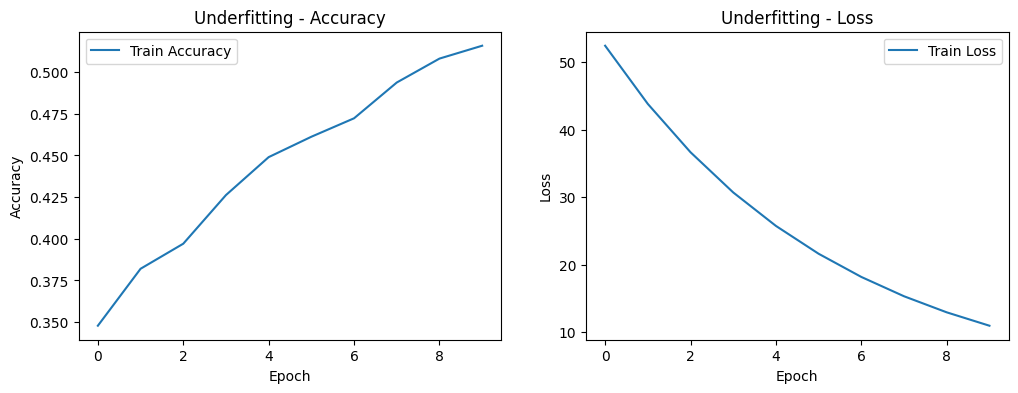

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6468 - loss: 10.0462
Test Accuracy: 0.6653


0.6653333306312561

In [16]:
# Cell 1: Create an underfitting model
# Goal: Design a simple ANN (e.g., few layers, small neurons) that underfits the data.
# Train it on the train set (no validation split needed here).
# Observe high bias: similar poor performance on train and test.
# After training, use plot_history(history, 'Underfitting') and evaluate_model(model)
model = Sequential([
    Dense(units=512, activation="relu" , input_shape=(X_all.shape[1],)) ,
    Dropout(0.5),
    Dense(units=256, activation="relu" , kernel_regularizer=l2(0.1)),
    Dropout(0.5),
    Dense(units=128, activation="relu" , kernel_regularizer=l2(0.1)),
    Dropout(0.5),
    Dense(units=32, activation="relu" , kernel_regularizer=l2(0.1)),
    Dropout(0.5),
    Dense(units=3, activation='softmax')
])
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy" , metrics=['accuracy'])
history = model.fit(
    X_all
    , y_all
    , epochs=10
  )
plot_history(history,"Underfitting")
evaluate_model(model , isHog=True)

Epoch 1/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6581 - loss: 0.7512
Epoch 2/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8882 - loss: 0.2932
Epoch 3/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9114 - loss: 0.2377
Epoch 4/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9232 - loss: 0.2040
Epoch 5/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9353 - loss: 0.1779
Epoch 6/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9406 - loss: 0.1591
Epoch 7/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9466 - loss: 0.1459
Epoch 8/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9522 - loss: 0.1292
Epoch 9/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9545 - loss: 0.1222
Epoch 10/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9594 - loss: 0.1086


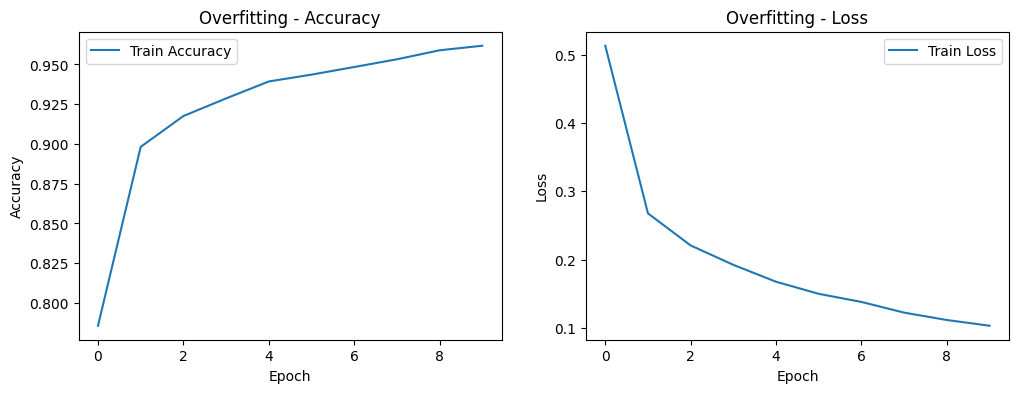

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9081 - loss: 0.3400
Test Accuracy: 0.9067


0.9066666960716248

In [7]:
# Cell 2: Create an overfitting model
# Goal: Design a complex ANN (e.g., many layers, large neurons) that overfits.
# Train for many epochs without regularization.
# Observe low bias but high variance: good on train, poor on test.
# After training, use plot_history(history, 'Overfitting') and evaluate_model(model)

# Your code here:

model = Sequential([
    Dense(units=64, activation="relu" , input_shape=(X_all.shape[1],)),
    Dense(units=16, activation="relu"),
    Dense(units=16, activation="relu"),
    Dense(units=3, activation='softmax')
])
model.compile(loss="categorical_crossentropy" , metrics=['accuracy'])
history = model.fit(X_all , y_all, epochs=10)
plot_history(history,"Overfitting")
evaluate_model(model , isHog=True)

Epoch 1/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.3397 - loss: 9.3181 - val_accuracy: 0.4894 - val_loss: 9.2373
Epoch 2/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5266 - loss: 9.2008 - val_accuracy: 0.6593 - val_loss: 9.0850
Epoch 3/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6991 - loss: 9.0343 - val_accuracy: 0.7820 - val_loss: 8.8922
Epoch 4/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.8059 - loss: 8.8336 - val_accuracy: 0.8278 - val_loss: 8.6902
Epoch 5/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.8455 - loss: 8.6346 - val_accuracy: 0.8421 - val_loss: 8.5142
Epoch 6/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.8582 - loss: 8.4658 - val_accuracy: 0.8517 - val_loss: 8.3712
Epoch 7/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8688 - loss: 8.3282 - val_accuracy: 0.8619 - val_loss: 8.2537
Epoch 8/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.8784 - loss: 8.2135 - 

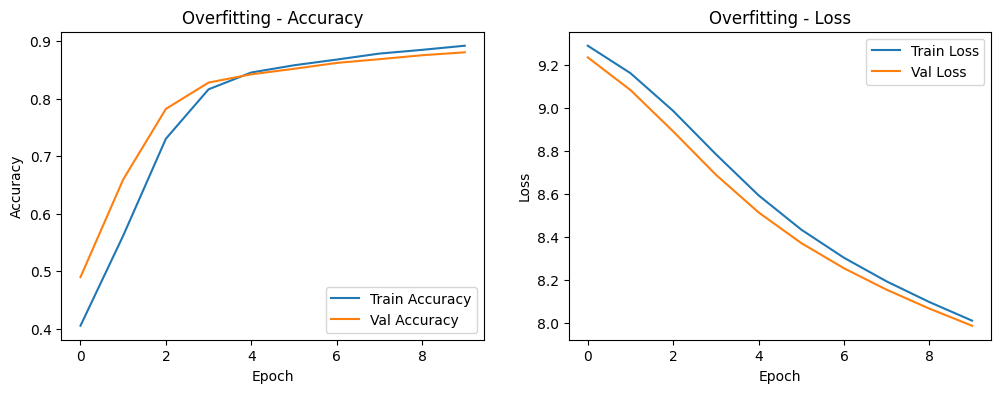

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8620 - loss: 8.0258
Test Accuracy: 0.8713


0.8713333606719971

In [17]:
# Cell 3: Add L1 Regularization
# Goal: Modify a model (perhaps the overfitting one) by adding L1 regularizers to layers.
# e.g., Dense(..., kernel_regularizer=l1(0.01))
# Train and observe how it reduces overfitting.
# Optional: Split validation from train if needed (e.g., validation_split=0.2 in fit)
# After training, plot and evaluate.

model = Sequential([
    Dense(units=512, activation="relu" , input_shape=(X_all.shape[1],)),
    Dense(units=256, activation="relu" , kernel_regularizer=l1(0.001)),
    Dense(units=128, activation="relu" , kernel_regularizer=l1(0.001)),
    Dense(units=32, activation="relu" , kernel_regularizer=l1(0.001)),
    Dense(units=3, activation='softmax')
])
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy" , metrics=['accuracy'])
history = model.fit(
    X_all
    , y_all
    , epochs=10
    , validation_split=0.2)
plot_history(history,"Overfitting")
evaluate_model(model , isHog=True)

Epoch 1/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.4136 - loss: 16.2741 - val_accuracy: 0.6189 - val_loss: 16.0466
Epoch 2/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.6601 - loss: 15.9616 - val_accuracy: 0.7628 - val_loss: 15.7046
Epoch 3/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.7700 - loss: 15.6118 - val_accuracy: 0.8093 - val_loss: 15.3488
Epoch 4/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.8122 - loss: 15.2586 - val_accuracy: 0.8295 - val_loss: 15.0167
Epoch 5/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.8351 - loss: 14.9365 - val_accuracy: 0.8404 - val_loss: 14.7236
Epoch 6/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.8496 - loss: 14.6506 - val_accuracy: 0.8551 - val_loss: 14.4581
Epoch 7/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 0.8604 - loss: 14.3893 - val_accuracy: 0.8677 - val_loss: 14.2118
Epoch 8/10
366/366 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.8723 - l

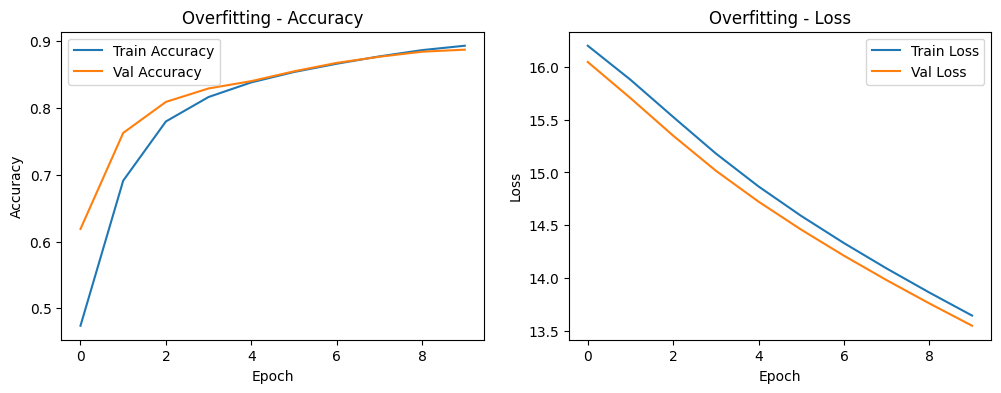

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8498 - loss: 13.5987
Test Accuracy: 0.8627


0.862666666507721

In [14]:
# Cell 4: Add L2 Regularization
# Goal: Similar to above, but use L2 (weight decay).
# e.g., Dense(..., kernel_regularizer=l2(0.01))
# Compare with L1.
# Optional validation split.
# Plot and evaluate.
model = Sequential([
    Dense(units=512, activation="relu" , input_shape=(X_all.shape[1],)),
    Dense(units=256, activation="relu" , kernel_regularizer=l2(0.001)),
    Dense(units=128, activation="relu" , kernel_regularizer=l2(0.001)),
    Dense(units=32, activation="relu" , kernel_regularizer=l2(0.001)),
    Dense(units=3, activation='softmax' )
])
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy" , metrics=['accuracy'])
history = model.fit(
    X_all
    , y_all
    , epochs=10
    , validation_split=0.2)
plot_history(history,"Overfitting")
evaluate_model(model , isHog=True)

Epoch 1/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.3418 - loss: 1.7011
Epoch 2/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3646 - loss: 1.6627
Epoch 3/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.3851 - loss: 1.6473
Epoch 4/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4279 - loss: 1.6235
Epoch 5/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.4699 - loss: 1.5881
Epoch 6/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5065 - loss: 1.5456
Epoch 7/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.5391 - loss: 1.5015
Epoch 8/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5576 - loss: 1.4563
Epoch 9/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.6029 - loss: 1.3928
Epoch 10/10
458/458 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.6159 - loss: 1.3559


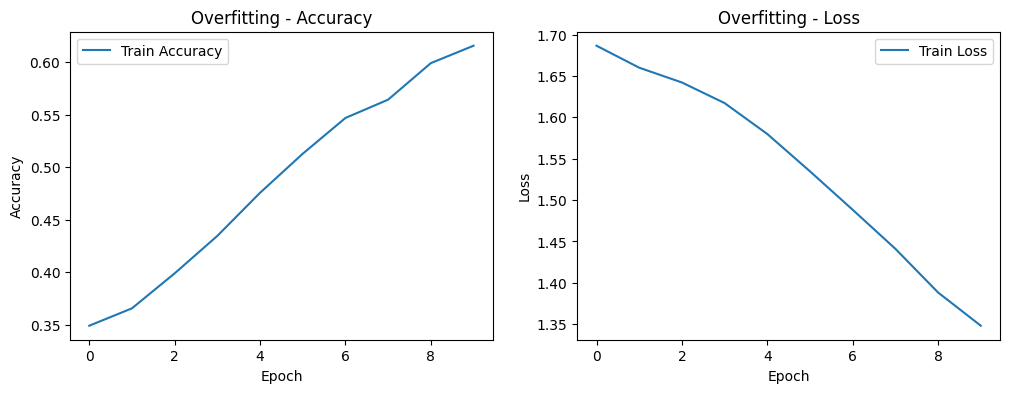

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6978 - loss: 1.2399
Test Accuracy: 0.7020


0.7020000219345093

In [18]:
# Cell 5: Add Dropout
# Goal: Add Dropout layers to prevent overfitting.
# e.g., Dropout(0.5) after Dense layers.
# Train, plot, evaluate.
# Optional validation.

model = Sequential([
    Dense(units=512, activation="relu" , input_shape=(X_all.shape[1],)) ,
    Dropout(0.5),
    Dense(units=256, activation="relu" , kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(units=128, activation="relu" , kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(units=32, activation="relu" , kernel_regularizer=l2(0.001)),
    Dropout(0.5),
    Dense(units=3, activation='softmax')
])
learning_rate = 0.001
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
model.compile(optimizer=optimizer,loss="categorical_crossentropy" , metrics=['accuracy'])
history = model.fit(
    X_all
    , y_all
    , epochs=10
  )
plot_history(history,"Overfitting")
evaluate_model(model , isHog=True)

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.6452 - loss: 0.9588 - val_accuracy: 0.8893 - val_loss: 0.4003
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.8707 - loss: 0.4516 - val_accuracy: 0.8947 - val_loss: 0.3644
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8950 - loss: 0.3696 - val_accuracy: 0.9105 - val_loss: 0.3286
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - accuracy: 0.8962 - loss: 0.3422 - val_accuracy: 0.9098 - val_loss: 0.3083
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.9028 - loss: 0.3099 - val_accuracy: 0.9183 - val_loss: 0.2875
Epoch 6/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8971 - loss: 0.3232 - val_accuracy: 0.9064 - val_loss: 0.2959
Epoch 7/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.8886 - loss: 0.3267 - val_accuracy: 0.9159 - val_loss: 0.2708
Epoch 8/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.9052 - loss: 0.2800 - val_ac

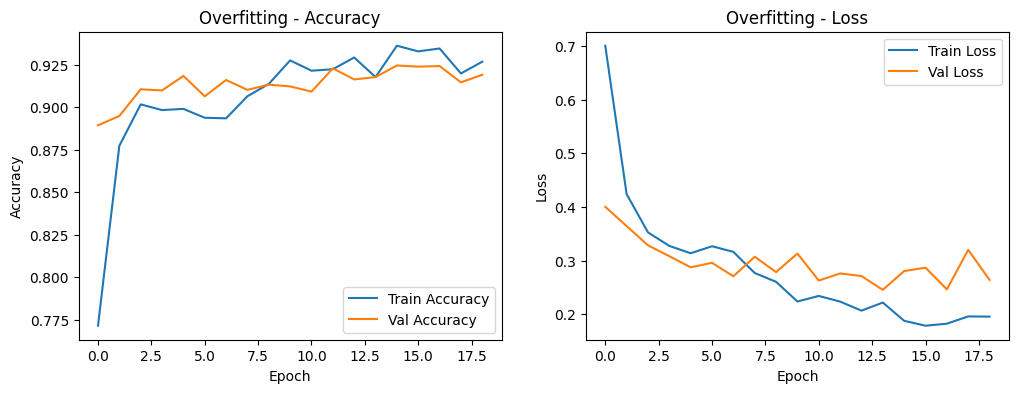

Test Accuracy: 0.9213333129882812


In [11]:
# Cell 6: Hyperparameter Tuning
# Goal: Experiment with hyperparameters like learning rate, batch size, epochs, optimizer.
# Use callbacks like EarlyStopping if needed.
# e.g., optimizer=Adam(learning_rate=0.001)
# Try different values and see impact.
# Must use validation split here to tune.
# Plot and evaluate the best one.

model = Sequential([
    Dense(256, activation="relu", input_shape=(X_all.shape[1],)),
    Dropout(0.3),
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=['accuracy'])

history = model.fit(
    X_all, y_all,
    epochs=50,
    validation_split=0.2,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

test_loss, test_acc = model.evaluate(X_test, y_test)
plot_history(history,"Overfitting")
print("Test Accuracy:", test_acc)

In [12]:
# Cell 7: Combined Approach
# Goal: Combine techniques (L1/L2, Dropout, Tuning) for balanced learning.
# Aim for good generalization: similar performance on train/val/test.
# Validation optional but recommended.
# Plot and evaluate.

# Your code here: